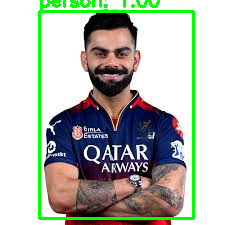

Number of people detected: 1


In [6]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from google.colab.patches import cv2_imshow

# ------------------------------
# Load model with updated API
# ------------------------------
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

# Load COCO labels
labels = weights.meta["categories"]

# ------------------------------
# Load image
# ------------------------------
img_path = "virat kohli.jpeg"   # change this
image = cv2.imread(img_path)
orig = image.copy()

# Convert to RGB and tensor
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb)
tensor = tensor.unsqueeze(0)

# ------------------------------
# Run detection
# ------------------------------
with torch.no_grad():
    predictions = model(tensor)

boxes = predictions[0]["boxes"]
scores = predictions[0]["scores"]
classes = predictions[0]["labels"]

# ------------------------------
# Draw boxes and count people
# ------------------------------
person_count = 0
for box, score, cls in zip(boxes, scores, classes):
    if score < 0.5:  # confidence threshold
        continue

    x1, y1, x2, y2 = box.int().tolist()
    detected_label = labels[cls]
    label_text = f"{detected_label}: {score:.2f}"

    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label_text, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    if detected_label == "person":
        person_count += 1

# ------------------------------
# Show result and print count
# ------------------------------
cv2_imshow(orig)
print(f"Number of people detected: {person_count}")
cv2.waitKey(0)
cv2.destroyAllWindows()

In [5]:
!pip install torch torchvision opencv-python